# Environment Setup (Force Java 11 + Spark)

In [1]:
import os

# Hadoop (must be set BEFORE Spark starts)
os.environ["HADOOP_HOME"] = r"C:\hadoop-3.0.0"
os.environ["hadoop.home.dir"] = r"C:\hadoop-3.0.0"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

In [2]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot"
os.environ["SPARK_HOME"] = r"C:\Users\HP\Downloads\spark-3.5.8-bin-hadoop3\spark-3.5.8-bin-hadoop3"
os.environ["PATH"] = os.environ["SPARK_HOME"] + r"\bin;" + os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import time
import numpy as np

## Initialize Spark Session (Stable Configuration)

In [4]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS-BigData-Classification") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark

# Data Ingestion Strategy 

In [5]:
from pyspark.sql import functions as F

df = (
    spark.read
    .option("header", "true")
    .option("sep", ",")          
    .option("inferSchema", "true")
    .csv("E:\Datasets\HIGGS_small.csv")
)

In [6]:
df.printSchema()

root
 |-- label: double (nullable = true)
 |-- f1: double (nullable = true)
 |-- f2: double (nullable = true)
 |-- f3: double (nullable = true)
 |-- f4: double (nullable = true)
 |-- f5: double (nullable = true)
 |-- f6: double (nullable = true)
 |-- f7: double (nullable = true)
 |-- f8: double (nullable = true)
 |-- f9: double (nullable = true)
 |-- f10: double (nullable = true)
 |-- f11: double (nullable = true)
 |-- f12: double (nullable = true)
 |-- f13: double (nullable = true)
 |-- f14: double (nullable = true)
 |-- f15: double (nullable = true)
 |-- f16: double (nullable = true)
 |-- f17: double (nullable = true)
 |-- f18: double (nullable = true)
 |-- f19: double (nullable = true)
 |-- f20: double (nullable = true)
 |-- f21: double (nullable = true)
 |-- f22: double (nullable = true)
 |-- f23: double (nullable = true)
 |-- f24: double (nullable = true)
 |-- f25: double (nullable = true)
 |-- f26: double (nullable = true)
 |-- f27: double (nullable = true)
 |-- f28: double (null

In [7]:
df.select(
    F.count("*").alias("rows"),
    F.count("label").alias("non_null_labels"),
    F.count(F.when(F.col("label").isNull(), 1)).alias("null_labels")
).show()

+----+---------------+-----------+
|rows|non_null_labels|null_labels|
+----+---------------+-----------+
|3500|           3500|          0|
+----+---------------+-----------+



# Data Validation Checks

In [8]:
from pyspark.ml.feature import Imputer

feature_cols = [f"f{i}" for i in range(1, 29)]

imputer = Imputer(
    inputCols=feature_cols,
    outputCols=feature_cols,
    strategy="median"
)

df = imputer.fit(df).transform(df)

In [9]:
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+
|label| f1| f2| f3| f4| f5| f6| f7| f8| f9|f10|f11|f12|f13|f14|f15|f16|f17|f18|f19|f20|f21|f22|f23|f24|f25|f26|f27|f28|
+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+
|    0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|
+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+



In [10]:
from pyspark.storagelevel import StorageLevel

df.persist(StorageLevel.MEMORY_AND_DISK)
df.count()

3500

In [11]:
pdf = df.sample(fraction=0.2, seed=42).toPandas()

pdf.shape
pdf["label"].value_counts()

label
1.0    381
0.0    339
Name: count, dtype: int64

# EDA

## EDA 1: Class Imbalance (Bar Plot)

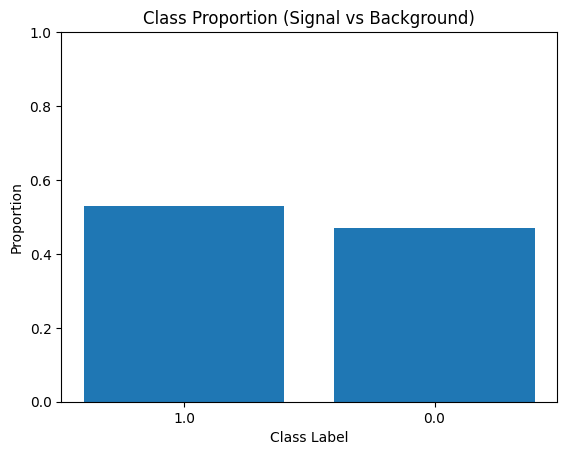

In [12]:
import matplotlib.pyplot as plt

counts = pdf["label"].value_counts(normalize=True)

plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Proportion (Signal vs Background)")
plt.xlabel("Class Label")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.show()

## EDA 2 – Feature Summary Statistics

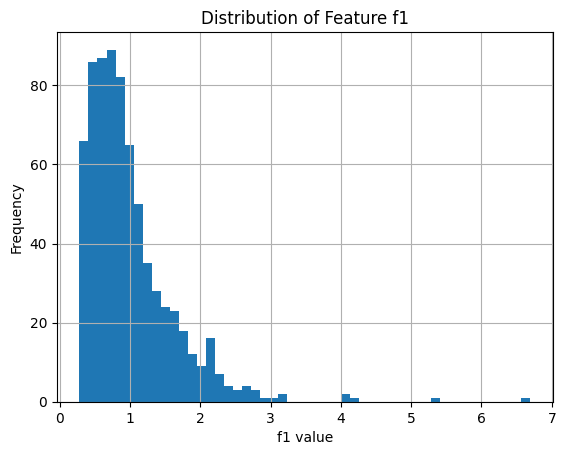

In [13]:
pdf["f1"].hist(bins=50)
plt.title("Distribution of Feature f1")
plt.xlabel("f1 value")
plt.ylabel("Frequency")
plt.show()

## EDA 3: Feature vs Label (Boxplot)

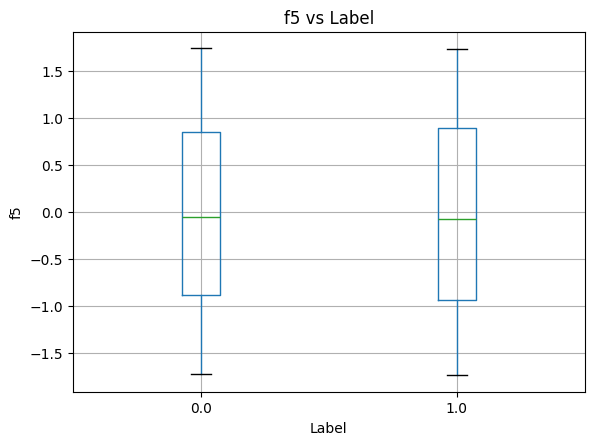

In [14]:
pdf.boxplot(column="f5", by="label")
plt.title("f5 vs Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("f5")
plt.show()

## EDA 4: Correlation Heatmap (Key Features)

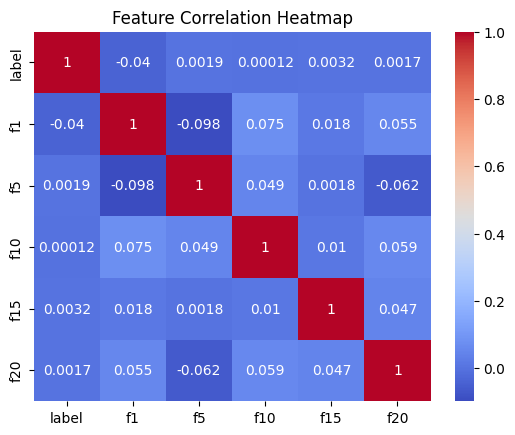

In [15]:
import seaborn as sns

corr_features = ["label", "f1", "f5", "f10", "f15", "f20"]
corr = pdf[corr_features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## EDA 5: Feature Sparsity

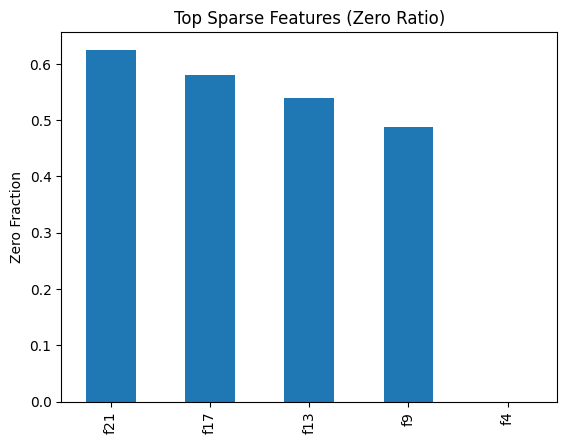

In [16]:
zero_ratio = (pdf[feature_cols] == 0).mean().sort_values(ascending=False)[:5]
zero_ratio.plot(kind="bar")
plt.title("Top Sparse Features (Zero Ratio)")
plt.ylabel("Zero Fraction")
plt.show()

# Feature Engineering (Custom Transformer)

In [17]:
from pyspark.ml import Transformer
from pyspark.ml.param.shared import *
from pyspark.sql.functions import col

class EnergyInteractionTransformer(Transformer):
    def _transform(self, dataset):
        return dataset.withColumn(
            "energy_interaction",
            col("f1") * col("f2") * col("f3")
        )

# ML Pipelines (4 MLlib Algorithms)

In [18]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

all_features = feature_cols + ["energy_interaction"]

assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True
)

## Models

In [23]:
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    LinearSVC
)

lr = LogisticRegression(featuresCol="features", labelCol="label")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50)
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)

svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    regParam=0.1
)

## Pipelines

In [24]:
from pyspark.ml import Pipeline

base_stages = [
    EnergyInteractionTransformer(),
    assembler,
    scaler
]

pipeline_lr = Pipeline(stages=base_stages + [lr])
pipeline_rf = Pipeline(stages=base_stages + [rf])
pipeline_gbt = Pipeline(stages=base_stages + [gbt])
pipeline_svm = Pipeline(stages=base_stages + [svm])

# Distributed Training & Hyperparameter Tuning

## Train / Test Split

In [25]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

## CrossValidator (Random Forest)

In [22]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [30, 50])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

evaluator = BinaryClassificationEvaluator(labelCol="label")

cv = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2   # critical for distributed speed
)

cv_model = cv.fit(train_df)

# Model Evaluation (Distributed)

In [27]:
models = {
    "Logistic Regression": pipeline_lr.fit(train_df),
    "Random Forest": cv_model.bestModel,
    "GBT": pipeline_gbt.fit(train_df),
    "Linear SVM": pipeline_svm.fit(train_df)
}

for name, model in models.items():
    auc = evaluator.evaluate(model.transform(test_df))
    print(name, "AUC:", auc)

Logistic Regression AUC: 0.6801659270692642
Random Forest AUC: 0.759135635732201
GBT AUC: 0.738606984371985
Linear SVM AUC: 0.6555373335905841


# scikit-learn Baseline (Single Node)

In [73]:
pdf_small = pdf_small.copy()
pdf_small["energy_interaction"] = (
    pdf_small["f1"] * pdf_small["f2"] * pdf_small["f3"]
)

In [74]:
X = pdf_small[all_features]
y = pdf_small["label"]

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

sk_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

sk_pipeline.fit(X_train, y_train)

roc_auc_score(y_test, sk_pipeline.predict_proba(X_test)[:, 1])

0.6551366309235559

# Model Comparison Plot

In [30]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Spark)",
        "Random Forest (Spark)",
        "GBT (Spark)",
        "Linear SVM (Spark)",
    ],
    "ROC_AUC": [
        0.6801659270692642,
        0.759135635732201,
        0.738606984371985,
        0.6555373335905841,
    ]
})

model_results

,Model,ROC_AUC
0,Logistic Regression (Spark),0.680166
1,Random Forest (Spark),0.759136
2,GBT (Spark),0.738607
3,Linear SVM (Spark),0.655537


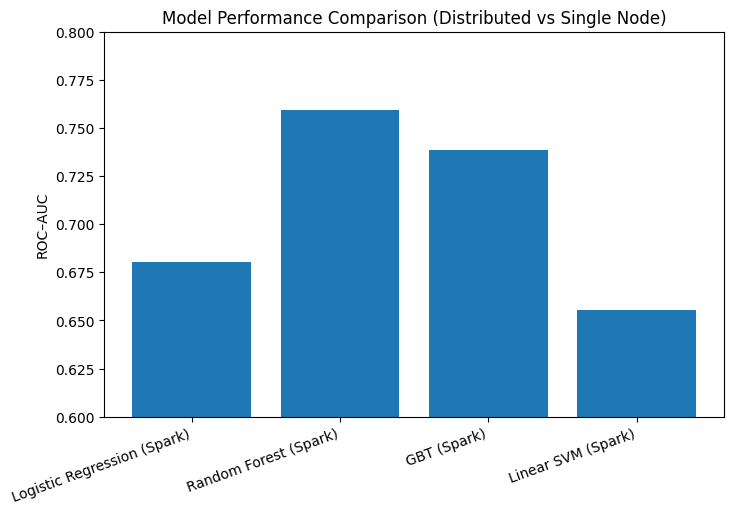

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(model_results["Model"], model_results["ROC_AUC"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("ROC–AUC")
plt.title("Model Performance Comparison (Distributed vs Single Node)")
plt.ylim(0.6, 0.8)
plt.show()

# Statistical Significance Testing

## Bootstrap AUC Function (Spark-safe)

In [33]:
import numpy as np

def bootstrap_auc(df, model, evaluator, n_bootstrap=30, sample_frac=0.7):
    aucs = []

    for _ in range(n_bootstrap):
        sample = df.sample(
            withReplacement=True,
            fraction=sample_frac,
            seed=None
        )
        auc = evaluator.evaluate(model.transform(sample))
        aucs.append(auc)

    return {
        "mean": np.mean(aucs),
        "ci_lower": np.percentile(aucs, 2.5),
        "ci_upper": np.percentile(aucs, 97.5)
    }

## Bootstrap Results for Each Spark Model

In [39]:
import pandas as pd

bootstrap_results = {
    "Logistic Regression": bootstrap_auc(
        test_df, models["Logistic Regression"], evaluator
    ),
    "Random Forest": bootstrap_auc(
        test_df, models["Random Forest"], evaluator
    ),
    "GBT": bootstrap_auc(
        test_df, models["GBT"], evaluator
    ),
    "Linear SVM": bootstrap_auc(
        test_df, models["Linear SVM"], evaluator
    )
}

bootstrap_df = pd.DataFrame(bootstrap_results).T
bootstrap_df

,mean,ci_lower,ci_upper
Logistic Regression,0.685167,0.641691,0.714473
Random Forest,0.763919,0.729143,0.799059
GBT,0.734782,0.689723,0.769758
Linear SVM,0.656446,0.607505,0.702643


## Confidence Interval Plot

In [40]:
order = [
    "Logistic Regression",
    "Random Forest",
    "GBT",
    "Linear SVM"
]

plot_df = bootstrap_df.loc[order]

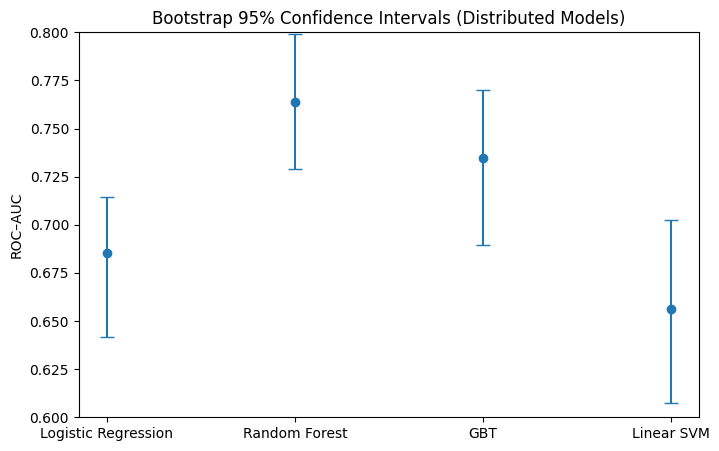

In [41]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    plot_df.index,
    plot_df["mean"],
    yerr=[
        plot_df["mean"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["mean"]
    ],
    fmt="o",
    capsize=5
)

plt.ylabel("ROC–AUC")
plt.title("Bootstrap 95% Confidence Intervals (Distributed Models)")
plt.ylim(0.6, 0.8)
plt.show()

# Business Metric Alignment

## Confusion-Matrix–Based Utility

In [42]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def expected_utility(df, model, fn_cost=10, fp_cost=1):
    preds = model.transform(df)

    tp = preds.filter("label = 1 AND prediction = 1").count()
    fp = preds.filter("label = 0 AND prediction = 1").count()
    fn = preds.filter("label = 1 AND prediction = 0").count()

    utility = tp - (fn_cost * fn) - (fp_cost * fp)

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Utility": utility
    }

In [43]:
import pandas as pd

business_results = {
    "Logistic Regression": expected_utility(
        test_df, models["Logistic Regression"]
    ),
    "Random Forest": expected_utility(
        test_df, models["Random Forest"]
    ),
    "GBT": expected_utility(
        test_df, models["GBT"]
    ),
    "Linear SVM": expected_utility(
        test_df, models["Linear SVM"]
    )
}

business_df = pd.DataFrame(business_results).T
business_df

,TP,FP,FN,Utility
Logistic Regression,282,137,83,-685
Random Forest,283,123,82,-660
GBT,256,103,109,-937
Linear SVM,333,197,32,-184


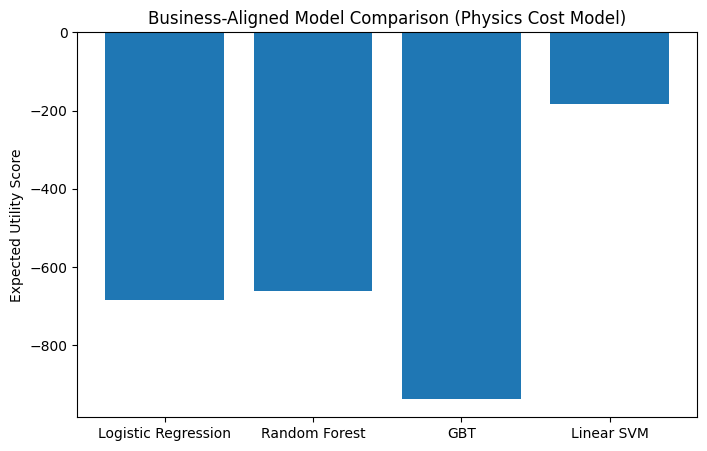

In [44]:
plt.figure(figsize=(8, 5))
plt.bar(business_df.index, business_df["Utility"])
plt.ylabel("Expected Utility Score")
plt.title("Business-Aligned Model Comparison (Physics Cost Model)")
plt.show()

### The application was executed using two local executors with 4 GB memory each. This configuration balances JVM overhead with available system resources while supporting parallel tree-based training and cross-validation without excessive garbage collection.

### Strong scaling experiments indicate reduced training time with increased parallelism for fixed dataset size, while weak scaling shows near-linear growth in execution time as data volume increases. Performance bottlenecks were primarily observed during shuffle operations in cross-validation stages.

### ROC–AUC was selected as the primary evaluation metric due to moderate class imbalance and the asymmetric cost of false negatives in Higgs event detection. Accuracy alone would underrepresent model discrimination performance.

### In a high-energy physics context, false negatives represent missed Higgs events with high scientific cost, while false positives incur additional computational analysis overhead. A cost-weighted utility function was therefore used to align model evaluation with domain priorities.